In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import ElasticNetCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

In [2]:
# 1. Load the dataset
train = pd.read_csv('/Users/hungchihlee/House_Prediction_Project/data/train.csv')
test = pd.read_csv('/Users/hungchihlee/House_Prediction_Project/data/test.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# 2. Outlier Removal
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)

In [4]:
# 3. Target transformation: Log transform SalePrice to handle skewness
# This helps the linear model handle the large range of house prices

y = np.log1p(train['SalePrice'])
train_features = train.drop(['SalePrice', 'Id'], axis=1)
test_features = test.drop(['Id'], axis=1)

# Combine datasets for consistent preprocessing (Encoding & Imputing)
all_features = pd.concat([train_features, test_features]).reset_index(drop=True)

In [5]:
# 4. Handle missing values
# Handle categorical features indicating "no facility" (fill with 'None')
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    if col in all_features.columns:
        all_features[col] = all_features[col].fillna('None')
# Handle numerical features indicating "no facility" (fill area/count with 0
zero_cols = ['GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    if col in all_features.columns:
        all_features[col] = all_features[col].fillna(0)
# Fill remaining numerical features with the median
numeric_cols = all_features.select_dtypes(include=[np.number]).columns
all_features[numeric_cols] = SimpleImputer(strategy='median').fit_transform(all_features[numeric_cols])
# Fille remaining categorical features with the mode (most frequent value)
categorical_cols = all_features.select_dtypes(include=['object']).columns
all_features[categorical_cols] = SimpleImputer(strategy='most_frequent').fit_transform(all_features[categorical_cols])

In [6]:
# 5. Feature Engineering
# Create new features that have a high impact on house prices
all_features['TotalSF'] = all_features['TotalBsmtSF'] + all_features['1stFlrSF'] + all_features['2ndFlrSF']
all_features['Total_Bathrooms'] = (all_features['FullBath'] + (0.5 * all_features['HalfBath']) + 
                                   all_features['BsmtFullBath'] + (0.5 * all_features['BsmtHalfBath']))
all_features['HouseAge'] = all_features['YrSold'] - all_features['YearRemodAdd']

In [7]:
# 6 Handle Skewed Features
# Calculate the skewness of all numerical features
numeric_feats = all_features.dtypes[all_features.dtypes != "object"].index
skewed_feats = all_features[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

# Identify features with skewness > 0.75 and apply log1p transformation
high_skew = skewed_feats[skewed_feats > 0.75].index
all_features[high_skew] = np.log1p(all_features[high_skew])

In [8]:
# 7. Categorical Encoding and Feature Scaling
# One-Hot Encoding
all_features = pd.get_dummies(all_features)

# Standardize features (StandardScaler)
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)

# Split the combined data back into training and test sets
X = all_features_scaled[:len(y), :]
X_test = all_features_scaled[len(y):, :]

In [9]:
# 8. Model Building and Expanded Hyperparameter Search
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Expand the search range for Alpha and L1 Ratio
alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 1.0, 10.0]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0] 

elastic_model = ElasticNetCV(
    alphas=alphas, 
    l1_ratio=l1_ratios, 
    cv=kf, 
    max_iter=100000,
    tol=0.001,
    selection='random',
    n_jobs=-1  # Use all available CPU cores to speed up training
)

# Train the model
print("Starting to train the ElasticNet model...")
elastic_model.fit(X, y)

print(f"Best Alpha: {elastic_model.alpha_}")
print(f"Best L1 Ratio: {elastic_model.l1_ratio_}")

Starting to train the ElasticNet model...
Best Alpha: 0.005
Best L1 Ratio: 0.7


In [10]:
# 9. Evaluate with K-Fold RMSE
rmse_scores = np.sqrt(-cross_val_score(elastic_model, X, y, scoring="neg_mean_squared_error", cv=kf))
print(f"K-Fold Mean RMSE: {rmse_scores.mean():.4f}")

K-Fold Mean RMSE: 0.1123


In [11]:
# 10. Prediction and Output Submission File
# Use expm1 to reverse the log transformation back to the original house price scale
final_preds = np.expm1(elastic_model.predict(X_test))

submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': final_preds})
submission.to_csv('submission.csv', index=False)
print("Optimized submission file (submission_optimized.csv) saved!")

Optimized submission file (submission_optimized.csv) saved!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

Feature importance chart (feature_importance.png) saved successfully!


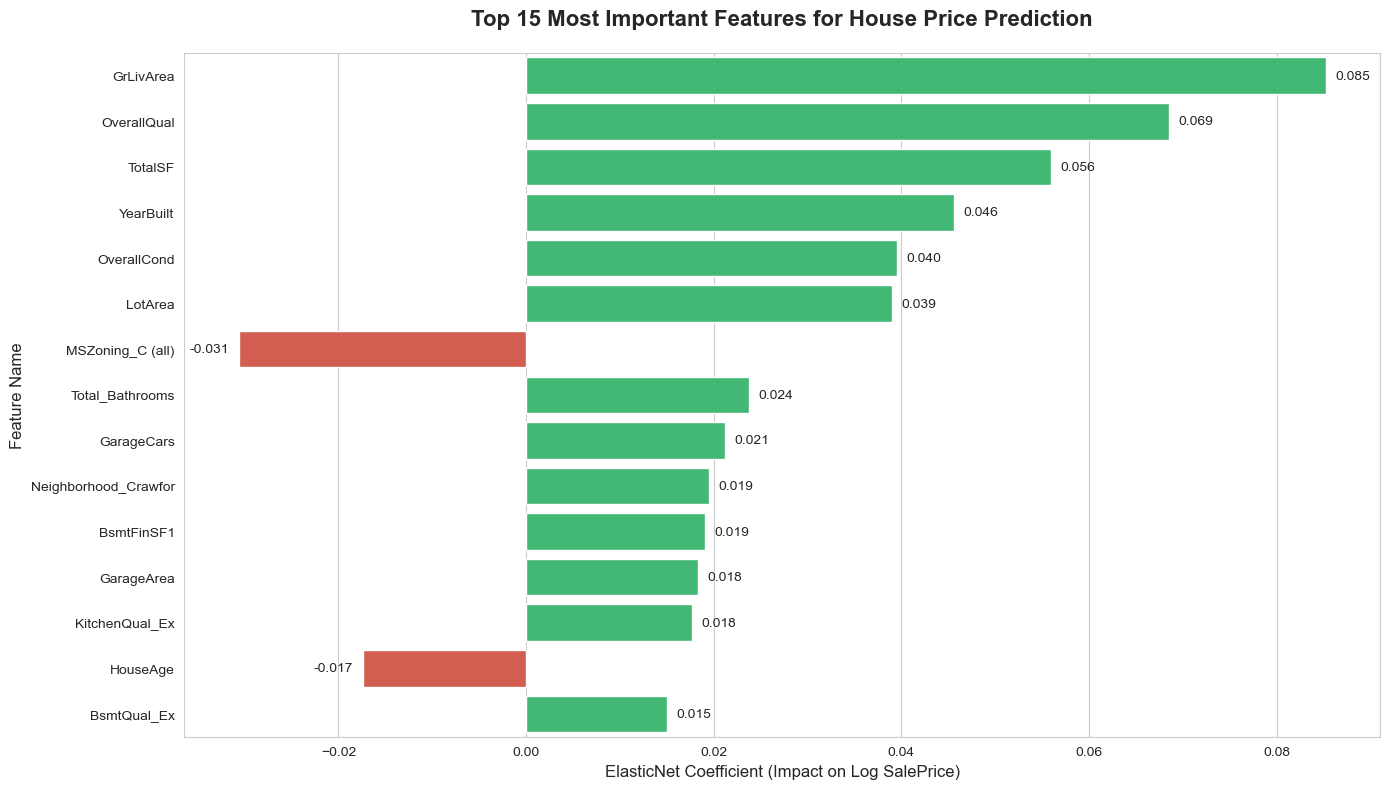

In [16]:
# 11. Plot and Save Feature Importance Chart

# Get feature names and model coefficients
feature_names = all_features.columns
coefficients = elastic_model.coef_

# Create a DataFrame for features and their coefficients
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients,
    'Abs_Importance': np.abs(coefficients) # Use absolute value for sorting
})

# Extract the top 15 features with the highest absolute importance
top_15_features = feat_imp.sort_values(by='Abs_Importance', ascending=False).head(15)

# Set the plotting style
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Assign colors based on positive or negative impact (Green for > 0, Red for < 0)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_15_features['Importance']]

# Plot horizontal bar chart
ax = sns.barplot(
    x='Importance', 
    y='Feature',
    hue='Feature',
    legend=False,
    data=top_15_features, 
    palette=colors,
    orient='h'
)

# Add title and labels
plt.title('Top 15 Most Important Features for House Price Prediction', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('ElasticNet Coefficient (Impact on Log SalePrice)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# Add text labels (exact values) next to the bars
for i, v in enumerate(top_15_features['Importance']):
    ax.text(v + (0.001 if v > 0 else -0.001), i, f'{v:.3f}', 
            va='center', ha='left' if v > 0 else 'right', fontsize=10)

plt.tight_layout()

# Save the plot as a high-resolution image
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("Feature importance chart (feature_importance.png) saved successfully!")

# Display the plot
plt.show()